# Linear Algebra for Data Science

A single running example — a synthetic **housing dataset** — used end-to-end across every core linear algebra concept in data science, from scalars to PCA.

**How this notebook works:**
- Run the cells top to bottom. The dataset is generated once in Section 0 and reused everywhere after — nothing is regenerated mid-notebook.
- Each section has: a plain-English explanation, why it matters in data science, and runnable code/visuals on the *same* dataset.
- Each section also links back to the YouTube resource from your study list.

**Requirements:** `numpy`, `pandas`, `matplotlib`, `scikit-learn`. Install if needed:

In [1]:
# !pip install numpy pandas matplotlib scikit-learn

## Table of Contents
0. [Setup & The Dataset](#0.-Setup-&-The-Dataset)
1. [Scalars & Vectors](#1.-Scalars-&-Vectors)
2. [Dot Product](#2.-Dot-Product)
3. [Cross Product](#3.-Cross-Product)
4. [Matrices](#4.-Matrices)
5. [Matrix Multiplication](#5.-Matrix-Multiplication)
6. [Systems of Linear Equations](#6.-Systems-of-Linear-Equations)
7. [Gaussian Elimination](#7.-Gaussian-Elimination)
8. [Matrix Inverse](#8.-Matrix-Inverse)
9. [Determinants](#9.-Determinants)
10. [Rank](#10.-Rank)
11. [Vector Spaces](#11.-Vector-Spaces)
12. [Span, Basis & Dimension](#12.-Span,-Basis-&-Dimension)
13. [Linear Independence](#13.-Linear-Independence)
14. [Orthogonality](#14.-Orthogonality)
15. [Projections](#15.-Projections)
16. [Norms](#16.-Norms)
17. [Cosine Similarity](#17.-Cosine-Similarity)
18. [Linear Transformations](#18.-Linear-Transformations)
19. [Eigenvalues & Eigenvectors](#19.-Eigenvalues-&-Eigenvectors)
20. [Positive Definite Matrices](#20.-Positive-Definite-Matrices)
21. [Singular Value Decomposition (SVD) & PCA](#21.-Singular-Value-Decomposition-(SVD)-&-PCA)

## 0. Setup & The Dataset

We generate **one synthetic housing dataset** and use it for every section below. Each row is a house; each column is a numeric feature. Building it ourselves (rather than importing a black-box dataset) means we know exactly which relationships are baked in — which makes it easy to *demonstrate* things like multicollinearity, regression, and PCA on purpose.

**Features:** `size_sqft`, `bedrooms`, `age_years`, `distance_to_city_km`, `garage_spaces`
**Target:** `price_1000s` (price in $1,000s), built as a linear combination of the features plus random noise — so it's a perfect playground for linear algebra.

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
np.set_printoptions(precision=3, suppress=True)
np.random.seed(42)

n = 120

size_sqft = np.random.normal(1800, 600, n).clip(500, 4500)
bedrooms = np.clip(np.round(size_sqft/550 + np.random.normal(0, 0.6, n)), 1, 6).astype(int)
age_years = np.round(np.random.uniform(0, 50, n), 1)
distance_to_city_km = np.round(np.clip(np.random.exponential(8, n), 0.5, 40), 1)
garage_spaces = np.clip(np.round(size_sqft/1600 + np.random.normal(0, 0.4, n)), 0, 3).astype(int)

noise = np.random.normal(0, 25, n)
price_1000s = np.round(
    50 + 0.12*size_sqft + 8*bedrooms - 0.9*age_years - 2.5*distance_to_city_km + 6*garage_spaces + noise, 1
)
price_1000s = np.clip(price_1000s, 40, None)

df = pd.DataFrame({
    'size_sqft': np.round(size_sqft),
    'bedrooms': bedrooms,
    'age_years': age_years,
    'distance_to_city_km': distance_to_city_km,
    'garage_spaces': garage_spaces,
    'price_1000s': price_1000s
})

feat_cols = ['size_sqft', 'bedrooms', 'age_years', 'distance_to_city_km', 'garage_spaces']

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (120, 6)


,size_sqft,bedrooms,age_years,distance_to_city_km,garage_spaces,price_1000s
0,2098.0,4,21.9,1.2,2,348.2
1,1717.0,3,3.9,11.5,1,239.4
2,2189.0,5,1.3,7.7,2,365.1
3,2714.0,4,48.1,0.9,2,345.9
4,1660.0,3,41.8,0.7,1,253.0


In [3]:
df.describe().round(2)

,size_sqft,bedrooms,age_years,distance_to_city_km,garage_spaces,price_1000s
count,120.00,120.00,120.00,120.00,120.00,120.00
mean,1754.78,3.21,24.66,10.23,1.04,246.07
std,549.48,1.26,14.88,10.04,0.57,87.96
min,500.00,1.00,0.50,0.50,0.00,40.00
25%,1457.25,2.00,12.48,2.60,1.00,192.10
50%,1756.00,3.00,24.65,7.00,1.00,249.25
75%,2029.25,4.00,37.52,14.00,1.00,302.92
max,3278.00,6.00,49.50,40.00,2.00,481.00


In [4]:
# Correlation matrix - notice size_sqft & bedrooms are fairly correlated (by design).
# We'll use this fact later (Rank, Linear Independence, Orthogonality).
df.corr().round(2)

,size_sqft,bedrooms,age_years,distance_to_city_km,garage_spaces,price_1000s
size_sqft,1.00,0.85,-0.06,-0.06,0.55,0.89
bedrooms,0.85,1.00,-0.03,-0.00,0.48,0.77
age_years,-0.06,-0.03,1.00,0.13,-0.14,-0.22
distance_to_city_km,-0.06,-0.00,0.13,1.00,-0.04,-0.38
garage_spaces,0.55,0.48,-0.14,-0.04,1.00,0.52
price_1000s,0.89,0.77,-0.22,-0.38,0.52,1.00


In [5]:
# X5: our data matrix (120 houses x 5 features). This single matrix is reused constantly below.
X5 = df[feat_cols].values.astype(float)
y = df['price_1000s'].values.astype(float)

# Standardized version (mean 0, std 1 per column) - needed whenever raw scale would distort a concept
# (e.g. size_sqft is in the thousands while bedrooms is a single digit).
Xstd = (X5 - X5.mean(axis=0)) / X5.std(axis=0)

print("X5 shape:", X5.shape)
print("First house, raw:        ", X5[0])
print("First house, standardized:", Xstd[0])

X5 shape: (120, 5)
First house, raw:         [2098.     4.    21.9    1.2    2. ]
First house, standardized: [ 0.627  0.633 -0.186 -0.903  1.686]


## 1. Scalars & Vectors

A **scalar** is a single number — just a magnitude (e.g. "2098 sq ft"). A **vector** is an ordered list of numbers — magnitude *and* direction once you picture it geometrically (e.g. "this house: [2098 sqft, 4 bed, 21.9 yrs, 1.2 km, 2 garage]").

> 📺 **Suggested watch:** 3Blue1Brown — search `3Blue1Brown vectors essence of linear algebra 1`

**Used in data science for:**
- Every row of a dataset is a **feature vector**; every single cell is a **scalar**.
- Model weights, gradients, embeddings — all vectors.
- Vector addition / scalar multiplication underlie almost every transformation we do to data (scaling, combining, averaging).

In [6]:
house0 = X5[0]
house1 = X5[1]

print("House 0 as a feature vector:", house0)
print("A single scalar (size of house 0):", df.iloc[0]['size_sqft'])

# scalar multiplication: what if this house were 10% bigger in every dimension?
print("Scaled by 1.1:", house0 * 1.1)

# vector addition: combining two houses' feature vectors
print("house0 + house1:", house0 + house1)

House 0 as a feature vector: [2098.     4.    21.9    1.2    2. ]
A single scalar (size of house 0): 2098.0
Scaled by 1.1: [2307.8     4.4    24.09    1.32    2.2 ]
house0 + house1: [3815.     7.    25.8   12.7    3. ]


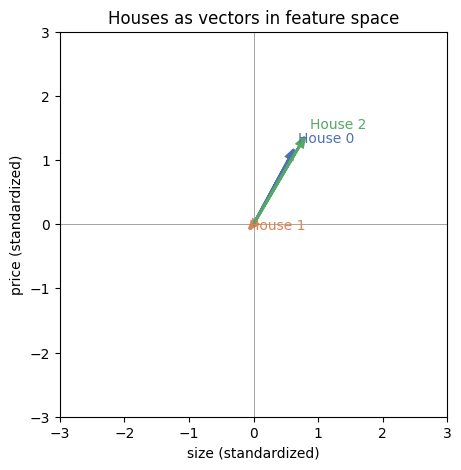

In [7]:
# Geometric intuition: plot two features (standardized) as arrows from the origin
feat2 = df[['size_sqft', 'price_1000s']].values
feat2_std = (feat2 - feat2.mean(axis=0)) / feat2.std(axis=0)

fig, ax = plt.subplots(figsize=(5, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']
for i in range(3):
    ax.arrow(0, 0, feat2_std[i, 0], feat2_std[i, 1], head_width=0.1,
              length_includes_head=True, color=colors[i], linewidth=2)
    ax.text(feat2_std[i, 0]*1.1, feat2_std[i, 1]*1.1, f'House {i}', color=colors[i])
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('size (standardized)'); ax.set_ylabel('price (standardized)')
ax.set_title('Houses as vectors in feature space')
plt.show()

## 2. Dot Product

The dot product multiplies two vectors element-wise and sums the results: $a \cdot b = \sum_i a_i b_i$. It also equals $|a||b|\cos(\theta)$, so it tells you how much two vectors point in the same direction.

> 📺 **Suggested watch:** 3Blue1Brown — search `3Blue1Brown dot product`

**Used in data science for:**
- A linear model's prediction *is* a dot product: `prediction = weights · features`.
- Measuring similarity/alignment between vectors (the basis for cosine similarity, attention mechanisms in transformers, etc.).
- Computing variance, covariance, and projections (coming up later).

In [8]:
weights = np.array([0.12, 8, -0.9, -2.5, 6])  # $ per sqft, per bedroom, per year of age, per km, per garage space

pred_house0 = np.dot(house0, weights) + 50
print("Predicted price via dot product:", round(pred_house0, 1))
print("Actual price:                   ", df.iloc[0]['price_1000s'])
print("(difference = the noise our model doesn't capture - completely normal)")

# the angle interpretation
cos_theta = np.dot(house0, house1) / (np.linalg.norm(house0) * np.linalg.norm(house1))
print(f"\ncos(angle) between house0 & house1 (raw features): {cos_theta:.4f}")
print("Notice this is suspiciously close to 1 (nearly 0 degrees) for two different houses!")
print("That's because size_sqft (in the thousands) dominates the vector's direction.")
print("We'll fix this with standardization in Section 17 (Cosine Similarity).")

Predicted price via dot product: 323.0
Actual price:                    348.2
(difference = the noise our model doesn't capture - completely normal)

cos(angle) between house0 & house1 (raw features): 0.9999
Notice this is suspiciously close to 1 (nearly 0 degrees) for two different houses!
That's because size_sqft (in the thousands) dominates the vector's direction.
We'll fix this with standardization in Section 17 (Cosine Similarity).


## 3. Cross Product

The cross product only exists in 3D (and a special case in 7D). $a \times b$ produces a *new vector* perpendicular to both $a$ and $b$, with magnitude equal to the area of the parallelogram they span.

> 📺 **Suggested watch:** 3Blue1Brown — search `3Blue1Brown cross product`

**Used in data science for:**
- Honestly: rarely, in typical tabular data science. It's central in **3D graphics, robotics, physics simulations, and computer vision** (e.g. computing surface normals, camera orientation).
- Included here for completeness — we'll borrow 3 of our 5 features and treat two houses as 3D vectors just to see it in action.

In [9]:
cols3 = ['size_sqft', 'bedrooms', 'age_years']
mean3, std3 = df[cols3].mean().values, df[cols3].std().values
a3 = (df.iloc[0][cols3].values.astype(float) - mean3) / std3
b3 = (df.iloc[1][cols3].values.astype(float) - mean3) / std3

cross = np.cross(a3, b3)
print("a x b =", cross)
print("Check: (a x b) . a =", np.dot(cross, a3), " (a x b) . b =", np.dot(cross, b3), " <- both ~0, confirms perpendicularity")

a x b = [-0.91   0.884 -0.06 ]
Check: (a x b) . a = 1.0106671283700213e-16  (a x b) . b = 2.135750428660978e-18  <- both ~0, confirms perpendicularity


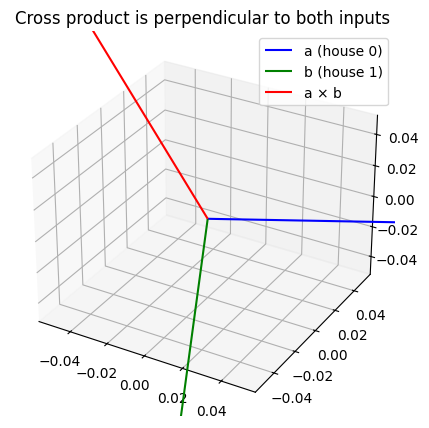

In [10]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(0, 0, 0, *a3, color='b', label='a (house 0)')
ax.quiver(0, 0, 0, *b3, color='g', label='b (house 1)')
ax.quiver(0, 0, 0, *cross, color='r', label='a × b')
ax.legend()
ax.set_title('Cross product is perpendicular to both inputs')
plt.show()

## 4. Matrices

A matrix is a 2D grid of numbers — rows and columns. You can think of it as a stack of vectors, or as a function that transforms one vector space into another.

> 📺 **Suggested watch:** 3Blue1Brown — search `3Blue1Brown matrices`

**Used in data science for:**
- **The entire dataset is a matrix**: rows = samples, columns = features. This is the single most common object in data science.
- Images are matrices (or stacks of them, for color channels). Weight layers in neural networks are matrices.

In [11]:
print("Our full data matrix X5 has shape", X5.shape, "-> 120 houses (rows) x 5 features (columns)")
print("\nFirst 3 rows (3 houses) as a matrix:\n", X5[:3])
print("\nColumn 0 (every house's size_sqft):", X5[:8, 0], "...")
print("Row 0 (every feature of house 0):   ", X5[0])

Our full data matrix X5 has shape (120, 5) -> 120 houses (rows) x 5 features (columns)

First 3 rows (3 houses) as a matrix:
 [[2098.     4.    21.9    1.2    2. ]
 [1717.     3.     3.9   11.5    1. ]
 [2189.     5.     1.3    7.7    2. ]]

Column 0 (every house's size_sqft): [2098. 1717. 2189. 2714. 1660. 1660. 2748. 2260.] ...
Row 0 (every feature of house 0):    [2098.     4.    21.9    1.2    2. ]


## 5. Matrix Multiplication

Multiplying matrix $A$ ($m\times k$) by matrix $B$ ($k \times p$) combines two linear transformations into one. The inner dimensions must match.

> 📺 **Suggested watch:** 3Blue1Brown — search `3Blue1Brown matrix multiplication`

**Used in data science for:**
- Predicting **all** rows at once: `X @ weights` computes every house's prediction in a single operation (no loops).
- The forward pass of a neural network is a chain of matrix multiplications.
- Computing the **Gram matrix** $X^TX$, which shows up everywhere from regression to covariance to PCA.

In [12]:
# Predict ALL 120 houses at once via matrix-vector multiplication (instead of looping row by row)
preds_all = X5 @ weights + 50
print("Predictions for first 5 houses:", preds_all[:5])
print("Actual prices for first 5 houses:", y[:5])

Predictions for first 5 houses: [323.05 253.78 344.26 374.14 239.83]
Actual prices for first 5 houses: [348.2 239.4 365.1 345.9 253. ]


In [13]:
# The Gram matrix: X^T X. Shows up constantly from here on (regression, covariance, rank, determinants...)
gram = X5.T @ X5
print("X^T X shape:", gram.shape, "(5x5, one row/col per feature)")
print(gram)

X^T X shape: (5, 5) (5x5, one row/col per feature)
[[4.054e+08 7.452e+05 5.139e+06 2.114e+06 2.399e+05]
 [7.452e+05 1.423e+03 9.424e+03 3.937e+03 4.420e+02]
 [5.139e+06 9.424e+03 9.932e+04 3.263e+04 2.939e+03]
 [2.114e+06 3.937e+03 3.263e+04 2.455e+04 1.250e+03]
 [2.399e+05 4.420e+02 2.939e+03 1.250e+03 1.690e+02]]


## 6. Systems of Linear Equations

A system of linear equations is a set of equations sharing the same variables, written compactly as $Ax = b$. Solving it means finding the $x$ that satisfies every equation at once.

> 📺 **Suggested watch:** 3Blue1Brown — search `3Blue1Brown systems of equations`

**Used in data science for:**
- Finding model parameters that *exactly* fit a small number of data points.
- The conceptual foundation for regression — when you have *more* equations (rows) than unknowns, it becomes the "least squares" problem we'll solve properly in Section 8 (Matrix Inverse) and Section 15 (Projections).

In [14]:
# Toy example: suppose price depended EXACTLY on just 3 features (size, bedrooms, age) for these 3 specific houses.
# That gives us 3 equations, 3 unknowns -> a square system Ax = b we can solve exactly.
idx = [0, 1, 2]
A3 = df.loc[idx, ['size_sqft', 'bedrooms', 'age_years']].values.astype(float)
b3 = df.loc[idx, 'price_1000s'].values.astype(float)

print("A (3x3):\n", A3)
print("b:", b3)

x_sol = np.linalg.solve(A3, b3)
print("\nSolved implied per-unit values [$/sqft, $/bedroom, $/year]:", x_sol)
print("Check A @ x_sol == b:", A3 @ x_sol, "vs", b3)
print("\n(These numbers look extreme because we forced an EXACT fit through only 3 points,")
print(" ignoring distance/garage/noise entirely. With more data we use least-squares instead - see Section 8.)")

A (3x3):
 [[2098.     4.    21.9]
 [1717.     3.     3.9]
 [2189.     5.     1.3]]
b: [348.2 239.4 365.1]

Solved implied per-unit values [$/sqft, $/bedroom, $/year]: [ 0.034 57.598  2.126]
Check A @ x_sol == b: [348.2 239.4 365.1] vs [348.2 239.4 365.1]

(These numbers look extreme because we forced an EXACT fit through only 3 points,
 ignoring distance/garage/noise entirely. With more data we use least-squares instead - see Section 8.)


## 7. Gaussian Elimination

Gaussian elimination is the systematic algorithm behind `np.linalg.solve`: row-reduce the augmented matrix $[A\,|\,b]$ to upper-triangular form, then back-substitute.

> 📺 **Suggested watch:** Khan Academy — search `Khan Academy Gaussian Elimination`

**Used in data science for:**
- It's what's happening *under the hood* whenever a library solves a linear system. Understanding it demystifies "black box" solvers and explains why some systems are numerically unstable (ties into Section 13, Linear Independence).

In [15]:
def gaussian_elimination(A, b, verbose=True):
    A = A.astype(float).copy()
    b = b.astype(float).copy()
    n_ = len(b)
    aug = np.hstack([A, b.reshape(-1, 1)])

    for col in range(n_):
        pivot_row = np.argmax(np.abs(aug[col:, col])) + col   # partial pivoting for stability
        if pivot_row != col:
            aug[[col, pivot_row]] = aug[[pivot_row, col]]
        for row in range(col + 1, n_):
            factor = aug[row, col] / aug[col, col]
            aug[row] -= factor * aug[col]
        if verbose:
            print(f"After eliminating column {col}:\n{aug}\n")

    x = np.zeros(n_)
    for row in range(n_ - 1, -1, -1):
        x[row] = (aug[row, -1] - aug[row, row+1:n_] @ x[row+1:n_]) / aug[row, row]
    return x

x_ge = gaussian_elimination(A3, b3)
print("Gaussian elimination solution:", x_ge)
print("Matches np.linalg.solve from Section 6:", np.allclose(x_ge, x_sol))

After eliminating column 0:
[[2189.       5.       1.3    365.1  ]
 [   0.      -0.922    2.88   -46.976]
 [   0.      -0.792   20.654   -1.722]]

After eliminating column 1:
[[2189.       5.       1.3    365.1  ]
 [   0.      -0.922    2.88   -46.976]
 [   0.       0.      18.179   38.643]]

After eliminating column 2:
[[2189.       5.       1.3    365.1  ]
 [   0.      -0.922    2.88   -46.976]
 [   0.       0.      18.179   38.643]]

Gaussian elimination solution: [ 0.034 57.598  2.126]
Matches np.linalg.solve from Section 6: True


## 8. Matrix Inverse

$A^{-1}$ is the matrix that "undoes" $A$: $AA^{-1} = I$. Only square, non-singular (full-rank) matrices have one.

> 📺 **Suggested watch:** Khan Academy — search `Khan Academy matrix inverse`

**Used in data science for:**
- The **Normal Equation**, the closed-form solution to linear regression: $w = (X^TX)^{-1}X^Ty$. This is how you fit a regression line *without* gradient descent, when $X^TX$ is invertible.

In [16]:
# Build the full design matrix: an intercept column of 1s + all 5 features
X_design = np.column_stack([np.ones(n), X5])
XtX = X_design.T @ X_design
XtX_inv = np.linalg.inv(XtX)

w_full = XtX_inv @ X_design.T @ y
print("Regression weights via the Normal Equation [intercept, size, bedrooms, age, distance, garage]:")
print(w_full)

# Cross-check against numpy's own least-squares solver
w_lstsq, *_ = np.linalg.lstsq(X_design, y, rcond=None)
print("\nnp.linalg.lstsq gives the same answer:", np.allclose(w_full, w_lstsq))

Regression weights via the Normal Equation [intercept, size, bedrooms, age, distance, garage]:
[53.317  0.119  8.641 -0.773 -2.766  3.652]

np.linalg.lstsq gives the same answer: True


## 9. Determinants

The determinant is a single number summarizing how a matrix scales area/volume. $\det(A)=0$ means $A$ is **singular** — it squashes space into a lower dimension and has no inverse.

> 📺 **Suggested watch:** 3Blue1Brown — search `3Blue1Brown determinant`

**Used in data science for:**
- A quick (if imperfect) invertibility check before computing $(X^TX)^{-1}$ — relevant whenever features are redundant or duplicated.
- Geometrically: $|\det|$ of two vectors = the area of the parallelogram they span.

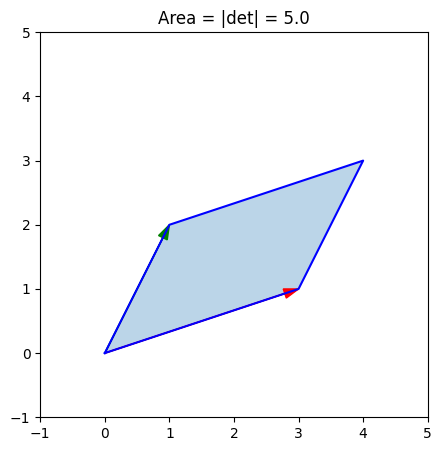

In [17]:
# Geometric intuition first: determinant = signed area of the parallelogram spanned by two vectors
v1, v2 = np.array([3., 1.]), np.array([1., 2.])
area = np.linalg.det(np.array([v1, v2]))

fig, ax = plt.subplots(figsize=(5, 5))
parallelogram = np.array([[0, 0], v1, v1 + v2, v2, [0, 0]])
ax.plot(parallelogram[:, 0], parallelogram[:, 1], 'b-')
ax.fill(parallelogram[:, 0], parallelogram[:, 1], alpha=0.3)
ax.arrow(0, 0, *v1, head_width=0.15, color='red', length_includes_head=True)
ax.arrow(0, 0, *v2, head_width=0.15, color='green', length_includes_head=True)
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.set_title(f'Area = |det| = {abs(area):.1f}')
plt.show()

In [18]:
print("det(X^T X) for our well-conditioned design matrix:", np.linalg.det(XtX))

# Now deliberately break it: add a redundant column (size in m^2, an exact linear function of size in sqft)
size_sqm = X_design[:, 1] * 0.0929
X_redundant = np.column_stack([X_design, size_sqm])
XtX_red = X_redundant.T @ X_redundant
det_red = np.linalg.det(XtX_red)
print("det(X^T X) WITH a perfectly redundant column:", det_red)
print(f"That's ~{np.linalg.det(XtX)/det_red:,.0f}x smaller than the clean version.")

print("\nIt's not EXACTLY zero, though - because our raw values are large (size_sqft in the thousands),")
print("floating-point rounding leaves tiny residual noise instead of a clean 0. This is a real, well-known")
print("numerical-precision pitfall. If we standardize first, the same redundancy gives a genuinely clean ~0:")

Xstd5 = (X5 - X5.mean(axis=0)) / X5.std(axis=0)
sqm_std = (size_sqm - size_sqm.mean()) / size_sqm.std()
X_red_std = np.column_stack([Xstd5, sqm_std])
print("det after standardizing first:", np.linalg.det(X_red_std.T @ X_red_std))
print("\n--> In practice, data scientists rely on RANK and CONDITION NUMBER (next two sections),")
print("    not 'is det exactly 0', because they're robust to this kind of scaling issue.")

det(X^T X) for our well-conditioned design matrix: 1.841359896203986e+21
det(X^T X) WITH a perfectly redundant column: 10289400235958.324
That's ~178,956,971x smaller than the clean version.

It's not EXACTLY zero, though - because our raw values are large (size_sqft in the thousands),
floating-point rounding leaves tiny residual noise instead of a clean 0. This is a real, well-known
numerical-precision pitfall. If we standardize first, the same redundancy gives a genuinely clean ~0:
det after standardizing first: -0.00013114216842029526

--> In practice, data scientists rely on RANK and CONDITION NUMBER (next two sections),
    not 'is det exactly 0', because they're robust to this kind of scaling issue.


## 10. Rank

The rank of a matrix is the number of linearly independent rows (or columns) — the *true* dimensionality of the information it contains.

> 📺 **Suggested watch:** StatQuest — search `StatQuest Matrix Rank`

**Used in data science for:**
- Detecting **redundant / duplicated features** (multicollinearity). If rank < number of columns, some features carry no new information.
- A robust, scale-independent alternative to "check if det = 0" (see the Section 9 caveat above).

In [19]:
print("Rank of our clean design matrix (6 columns: intercept + 5 features):", np.linalg.matrix_rank(X_design))
print("Rank AFTER adding the redundant size_sqm column (7 columns):        ", np.linalg.matrix_rank(X_redundant))
print("\nIt stayed at 6, not 7 - the new column added a column, but zero NEW information.")
print("This is exactly what rank is built to catch, and it didn't get fooled by the scaling issue that tripped up the raw determinant.")

Rank of our clean design matrix (6 columns: intercept + 5 features): 6
Rank AFTER adding the redundant size_sqm column (7 columns):         6

It stayed at 6, not 7 - the new column added a column, but zero NEW information.
This is exactly what rank is built to catch, and it didn't get fooled by the scaling issue that tripped up the raw determinant.


## 11. Vector Spaces

A vector space is a set of vectors closed under addition and scalar multiplication — add or scale any vectors in the set, and you stay inside the set. Our 5 numeric features live in $\mathbb{R}^5$.

> 📺 **Suggested watch:** MIT OpenCourseWare — search `MIT Linear Algebra Vector Spaces Gilbert Strang`

**Used in data science for:**
- The **feature space** itself is a vector space. Every operation we do — scaling features, averaging samples, taking linear combinations for a new engineered feature — relies on this closure property holding.

In [20]:
v_a, v_b = X5[0], X5[1]
combo = 0.3 * v_a + 0.7 * v_b   # a linear combination (weighted average) of two houses

print("0.3*house0 + 0.7*house1 =", combo)
print("Still a 5-dimensional vector:", combo.shape, "-> still lives in the same space R^5.")
print("This 'closure' property is what makes linear combinations (and so much of linear algebra) well-defined.")

0.3*house0 + 0.7*house1 = [1831.3     3.3     9.3     8.41    1.3 ]
Still a 5-dimensional vector: (5,) -> still lives in the same space R^5.
This 'closure' property is what makes linear combinations (and so much of linear algebra) well-defined.


## 12. Span, Basis & Dimension

The **span** of a set of vectors is every linear combination you can build from them. A **basis** is a minimal spanning set (linearly independent). The **dimension** is the number of vectors in that basis.

> 📺 **Suggested watch:** MIT OpenCourseWare — search `MIT Basis Span Dimension Gilbert Strang`

**Used in data science for:**
- Feature engineering is, at its core, asking "does my feature set *span* the information I need?"
- PCA (Section 21) finds a *new*, smaller basis that still spans (almost) the same space — that's the entire point of dimensionality reduction.

In [21]:
I5 = np.eye(5)
print("The standard basis for R^5 (one vector per feature):\n", I5)

# Any house vector is trivially a linear combination of the standard basis
house0_reconstructed = sum(X5[0, i] * I5[i] for i in range(5))
print("\nReconstructing house 0 from the standard basis:", house0_reconstructed)
print("Matches original house 0:", np.allclose(house0_reconstructed, X5[0]))

print("\nDimension of our feature space (= rank of X5):", np.linalg.matrix_rank(X5))
print("All 5 features are pulling independent weight - the dimension equals the number of features.")

The standard basis for R^5 (one vector per feature):
 [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]

Reconstructing house 0 from the standard basis: [2098.     4.    21.9    1.2    2. ]
Matches original house 0: True

Dimension of our feature space (= rank of X5): 5
All 5 features are pulling independent weight - the dimension equals the number of features.


## 13. Linear Independence

A set of vectors is linearly independent if no vector in it can be written as a combination of the others. The moment one *can* be, you have **redundancy** — and rank drops.

> 📺 **Suggested watch:** MIT OpenCourseWare — search `MIT Linear Independence Gilbert Strang`

**Used in data science for:**
- **Multicollinearity**: when features are near-dependent (like our `size_sqft` and `bedrooms`, correlation ≈0.85), regression coefficients become unstable — small changes in data cause big swings in the fitted weights.
- The **condition number** quantifies *how close* to dependent a matrix's columns are, which is a much better early-warning signal than waiting for rank to literally drop.

In [22]:
cond_clean = np.linalg.cond(X_design)
cond_redundant = np.linalg.cond(X_redundant)

print(f"Condition number, clean design matrix:        {cond_clean:,.1f}")
print(f"Condition number, WITH the redundant column:   {cond_redundant:,.1e}")
print("\nThe jump from ~10^3 to ~10^17 is the real signal of near-dependence -")
print("rank alone (Section 10) caught the exact redundancy, but condition number catches the 'almost' cases too,")
print("like our genuinely-present (but not perfect) size_sqft / bedrooms correlation.")

Condition number, clean design matrix:        7,362.4
Condition number, WITH the redundant column:   1.1e+17

The jump from ~10^3 to ~10^17 is the real signal of near-dependence -
rank alone (Section 10) caught the exact redundancy, but condition number catches the 'almost' cases too,
like our genuinely-present (but not perfect) size_sqft / bedrooms correlation.


## 14. Orthogonality

Two vectors are orthogonal if their dot product is 0 — geometrically, they're at 90° and share no "directional overlap." Orthogonal vectors carry maximally non-redundant information.

> 📺 **Suggested watch:** 3Blue1Brown — search `3Blue1Brown orthogonality`

**Used in data science for:**
- Orthogonal **features** are ideal: each one adds genuinely new information (no multicollinearity).
- PCA's principal components are *always* orthogonal to each other by construction (Section 21).
- **Gram-Schmidt** turns any set of vectors into an orthogonal set — the basis of QR decomposition.

In [23]:
corr = np.corrcoef(X5.T)
abs_corr_no_diag = np.abs(corr) + np.eye(5) * 99   # mask the diagonal so we can find the smallest off-diagonal
i, j = np.unravel_index(np.argmin(abs_corr_no_diag), abs_corr_no_diag.shape)
print(f"Most nearly-orthogonal feature pair: {feat_cols[i]} & {feat_cols[j]}  (correlation={corr[i, j]:.3f})")

a_, b_ = Xstd[:, 0], Xstd[:, 1]  # size & bedrooms - our most CORRELATED (least orthogonal) pair
print(f"\nDot product of standardized size & bedrooms (correlated pair): {np.dot(a_, b_):.2f}  <- far from 0")

Most nearly-orthogonal feature pair: bedrooms & distance_to_city_km  (correlation=-0.000)

Dot product of standardized size & bedrooms (correlated pair): 101.76  <- far from 0


In [24]:
def gram_schmidt(v1, v2):
    u1 = v1
    u2 = v2 - (np.dot(v2, u1) / np.dot(u1, u1)) * u1   # subtract out the part of v2 that overlaps with u1
    return u1, u2

u1, u2 = gram_schmidt(a_, b_)
print("Dot product AFTER Gram-Schmidt orthogonalization:", np.dot(u1, u2))
print("(effectively 0 - u1 and u2 are now perpendicular, even though the originals weren't)")

Dot product AFTER Gram-Schmidt orthogonalization: 1.3654459804027582e-14
(effectively 0 - u1 and u2 are now perpendicular, even though the originals weren't)


## 15. Projections

Projecting vector $a$ onto vector $b$ finds the "shadow" $a$ casts on $b$: $\text{proj}_b(a) = \frac{a\cdot b}{b \cdot b}b$. Projecting onto a whole *space* (not just one vector) generalizes this.

> 📺 **Suggested watch:** 3Blue1Brown — search `3Blue1Brown projection vectors`

**Used in data science for:**
- **Least-squares regression IS a projection.** The fitted values $\hat{y}$ are exactly the projection of the true $y$ onto the column space of $X$ — the closest point in "achievable predictions" space to the real answer.

In [25]:
def project(a, onto):
    return (np.dot(a, onto) / np.dot(onto, onto)) * onto

# The regression fitted values from Section 8 ARE a projection of y onto the column space of X
y_hat = X_design @ w_full
proj_formula = X_design @ (XtX_inv @ (X_design.T @ y))   # the projection matrix, applied directly to y
print("Regression predictions match the projection formula exactly:", np.allclose(y_hat, proj_formula))

residual = y - y_hat
print("\nResidual (y - y_hat) dotted with each column of X:", X_design.T @ residual)
print("All ~0 - the leftover error is PERPENDICULAR to every feature.")
print("That's not a coincidence: it's the defining property of a projection (you can't get any closer).")

Regression predictions match the projection formula exactly: True

Residual (y - y_hat) dotted with each column of X: [0. 0. 0. 0. 0. 0.]
All ~0 - the leftover error is PERPENDICULAR to every feature.
That's not a coincidence: it's the defining property of a projection (you can't get any closer).


## 16. Norms

A norm measures a vector's "size." **L1** (sum of absolute values), **L2** (Euclidean length, $\sqrt{\sum x_i^2}$), and **L∞** (max absolute value) are the three you'll see constantly.

> 📺 **Suggested watch:** StatQuest — search `StatQuest L1 L2 Norm`

**Used in data science for:**
- **Regularization**: Lasso penalizes the L1 norm of weights (encourages sparsity/feature selection), Ridge penalizes the L2 norm (shrinks weights smoothly).
- Distance metrics, gradient clipping, evaluating error magnitude (e.g. RMSE *is* an L2 norm of residuals).

In [26]:
v = X5[0]
print(f"House 0 vector: {v}")
print(f"L1 norm:  {np.sum(np.abs(v)):.2f}")
print(f"L2 norm:  {np.linalg.norm(v):.2f}")
print(f"L∞ norm:  {np.max(np.abs(v)):.2f}")

print(f"\nL2 norm of our regression residuals (total error magnitude): {np.linalg.norm(residual):.2f}")

House 0 vector: [2098.     4.    21.9    1.2    2. ]
L1 norm:  2127.10
L2 norm:  2098.12
L∞ norm:  2098.00

L2 norm of our regression residuals (total error magnitude): 281.08


In [27]:
# Ridge regression = Normal Equation + an L2 penalty added directly into the matrix being inverted
lam = 5
w_ridge = np.linalg.inv(XtX + lam * np.eye(XtX.shape[0])) @ X_design.T @ y

print("OLS weights:  ", w_full)
print("Ridge weights:", w_ridge)
print("\nRidge shrinks the weights toward 0 - notice the intercept and bedroom coefficient move the most.")

OLS weights:   [53.317  0.119  8.641 -0.773 -2.766  3.652]
Ridge weights: [31.961  0.13   7.072 -0.616 -2.623  3.885]

Ridge shrinks the weights toward 0 - notice the intercept and bedroom coefficient move the most.


## 17. Cosine Similarity

Cosine similarity is the dot product normalized by both vectors' lengths: $\cos(\theta) = \frac{a \cdot b}{|a||b|}$. It measures *directional* similarity, ignoring magnitude entirely.

> 📺 **Suggested watch:** StatQuest — search `StatQuest Cosine Similarity`

**Used in data science for:**
- **Recommendation systems** ("find me items/users similar to this one").
- Text/document similarity (comparing TF-IDF or embedding vectors).
- Crucially — this is why we standardize first (Section 2 showed raw cosine similarity was nearly useless here, dominated by `size_sqft`'s scale).

In [28]:
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

sims5 = np.array([[cosine_sim(Xstd[i], Xstd[j]) for j in range(5)] for i in range(5)])
print("Cosine similarity matrix, first 5 houses (STANDARDIZED features this time):")
print(sims5)
print("\nMuch more informative than Section 2's raw-feature version (everything ~0.9999) -")
print("now we get real spread, from -0.79 to 0.96.")

Cosine similarity matrix, first 5 houses (STANDARDIZED features this time):
[[ 1.    -0.042  0.792  0.742  0.095]
 [-0.042  1.     0.436 -0.607 -0.786]
 [ 0.792  0.436  1.     0.326 -0.482]
 [ 0.742 -0.607  0.326  1.     0.462]
 [ 0.095 -0.786 -0.482  0.462  1.   ]]

Much more informative than Section 2's raw-feature version (everything ~0.9999) -
now we get real spread, from -0.79 to 0.96.


In [29]:
# Find the house most similar to house 0 across the WHOLE dataset
query = Xstd[0]
all_sims = np.array([cosine_sim(query, Xstd[k]) for k in range(n)])
order = np.argsort(-all_sims)
most_similar = order[1]  # skip index 0 (itself, similarity=1)

print(f"House most similar to house 0 -> house {most_similar} (similarity={all_sims[most_similar]:.3f})")
print("\nHouse 0:", df.iloc[0][feat_cols].to_dict())
print(f"House {most_similar}:", df.iloc[most_similar][feat_cols].to_dict())

House most similar to house 0 -> house 9 (similarity=0.961)

House 0: {'size_sqft': 2098.0, 'bedrooms': 4.0, 'age_years': 21.9, 'distance_to_city_km': 1.2, 'garage_spaces': 2.0}
House 9: {'size_sqft': 2126.0, 'bedrooms': 4.0, 'age_years': 12.5, 'distance_to_city_km': 0.7, 'garage_spaces': 2.0}


## 18. Linear Transformations

A linear transformation is a function between vector spaces that preserves addition and scalar multiplication — and every one can be written as multiplication by a matrix. Rotation, scaling, and shearing are the classic examples.

> 📺 **Suggested watch:** 3Blue1Brown — search `3Blue1Brown linear transformations`

**Used in data science for:**
- Feature **scaling/standardizing** is (almost) a linear transform — note pure mean-centering is technically a *translation*, so it's the scaling part that's strictly linear.
- PCA (Section 21) is fundamentally a **rotation** of your data into a new coordinate system.
- Every "linear" layer in a neural network applies a linear transformation (plus a bias).

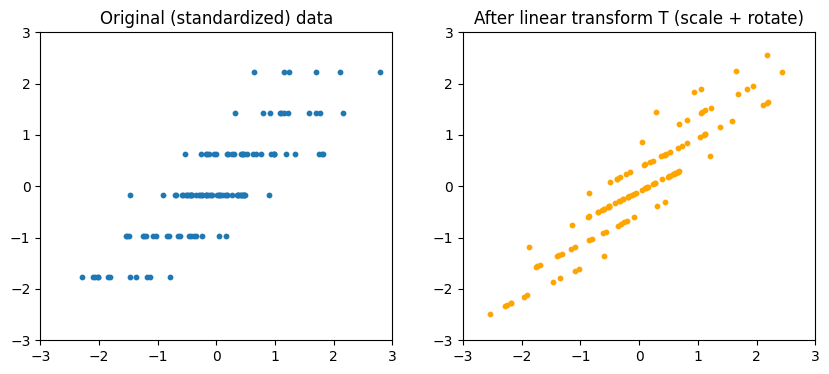

Transformation matrix T:
 [[ 1.299 -0.25 ]
 [ 0.75   0.433]]


In [30]:
# Apply a rotate+scale transformation matrix to 2 standardized features and see what happens visually
pts = Xstd[:, [0, 1]]   # size & bedrooms, standardized

theta = np.radians(30)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])  # rotation
S = np.array([[1.5, 0], [0, 0.5]])                                                 # scaling
T = R @ S   # combined transformation matrix

transformed = pts @ T.T

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(pts[:, 0], pts[:, 1], s=10)
axes[0].set_title('Original (standardized) data')
axes[0].set_xlim(-3, 3); axes[0].set_ylim(-3, 3)
axes[1].scatter(transformed[:, 0], transformed[:, 1], s=10, color='orange')
axes[1].set_title('After linear transform T (scale + rotate)')
axes[1].set_xlim(-3, 3); axes[1].set_ylim(-3, 3)
plt.show()

print("Transformation matrix T:\n", T)

## 19. Eigenvalues & Eigenvectors

For a square matrix $A$, an eigenvector $v$ is a direction that $A$ doesn't rotate — it only stretches it: $Av = \lambda v$. The scalar $\lambda$ is the eigenvalue (the stretch factor).

> 📺 **Suggested watch:** 3Blue1Brown — search `3Blue1Brown eigenvectors eigenvalues`

**Used in data science for:**
- **PCA** (next section) finds the eigenvectors of the covariance matrix — they *are* the principal components, and their eigenvalues *are* the variance explained.
- Google's original PageRank is the dominant eigenvector of a web-link matrix. Stability analysis of dynamical systems, spectral clustering, and more all lean on eigen-decomposition.

In [31]:
cov = np.cov(Xstd.T)   # 5x5 covariance matrix of our standardized features
eigvals, eigvecs = np.linalg.eigh(cov)   # eigh: symmetric-matrix-safe eigendecomposition, ascending order

print("Eigenvalues (ascending):", eigvals)
print("\nVerifying A v = lambda v for every eigenpair:")
for i in range(5):
    lhs = cov @ eigvecs[:, i]
    rhs = eigvals[i] * eigvecs[:, i]
    print(f"  eigenvalue {eigvals[i]:.3f}: A@v matches lambda*v -> {np.allclose(lhs, rhs)}")

Eigenvalues (ascending): [0.147 0.569 0.882 1.141 2.303]

Verifying A v = lambda v for every eigenpair:
  eigenvalue 0.147: A@v matches lambda*v -> True
  eigenvalue 0.569: A@v matches lambda*v -> True
  eigenvalue 0.882: A@v matches lambda*v -> True
  eigenvalue 1.141: A@v matches lambda*v -> True
  eigenvalue 2.303: A@v matches lambda*v -> True


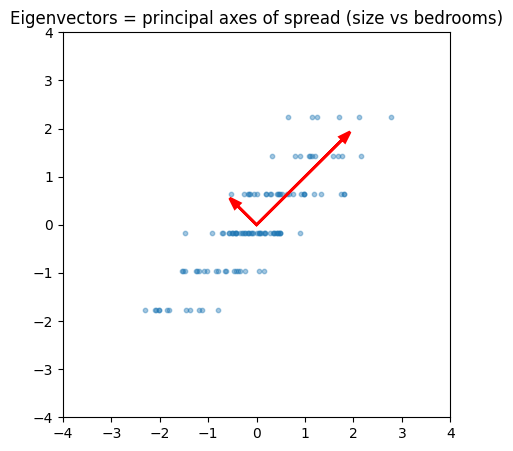

In [32]:
# Visualize on just 2 features: the eigenvectors of THEIR 2x2 covariance point along the data's natural axes of spread
cov2 = np.cov(Xstd[:, [0, 1]].T)
ev2, evec2 = np.linalg.eigh(cov2)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(Xstd[:, 0], Xstd[:, 1], s=10, alpha=0.4)
for i in range(2):
    vec = evec2[:, i] * np.sqrt(ev2[i]) * 2   # scale for visibility
    ax.arrow(0, 0, vec[0], vec[1], head_width=0.15, color='red', length_includes_head=True, linewidth=2)
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.set_title('Eigenvectors = principal axes of spread (size vs bedrooms)')
plt.show()

## 20. Positive Definite Matrices

A symmetric matrix $A$ is positive definite if $x^TAx > 0$ for every nonzero vector $x$ — equivalently, *all* of its eigenvalues are positive. Geometrically, it defines a bowl shape, never a saddle.

> 📺 **Suggested watch:** StatQuest — search `StatQuest Positive Definite Matrix`

**Used in data science for:**
- **Covariance matrices are always positive semi-definite** by construction — this is *why* variance can never be negative.
- Checking a loss function's **Hessian** is positive definite confirms you're at a genuine minimum (convex bowl), not a saddle point — central to optimization.
- Kernel matrices in SVMs must be positive semi-definite (Mercer's theorem) to correspond to a valid similarity measure.

In [33]:
def is_positive_definite(M):
    try:
        np.linalg.cholesky(M)   # Cholesky decomposition only succeeds for positive definite matrices
        return True
    except np.linalg.LinAlgError:
        return False

print("Is our covariance matrix positive definite?", is_positive_definite(cov))
print("All eigenvalues > 0?", np.all(eigvals > 0), "  ->", eigvals)

# A deliberately non-positive-definite matrix for contrast
M_bad = np.array([[1., 2.], [2., 1.]])
print("\nIs [[1,2],[2,1]] positive definite?", is_positive_definite(M_bad))
print("Its eigenvalues:", np.linalg.eigvalsh(M_bad), "<- one is negative, so it's NOT positive definite")

Is our covariance matrix positive definite? True
All eigenvalues > 0? True   -> [0.147 0.569 0.882 1.141 2.303]

Is [[1,2],[2,1]] positive definite? False
Its eigenvalues: [-1.  3.] <- one is negative, so it's NOT positive definite


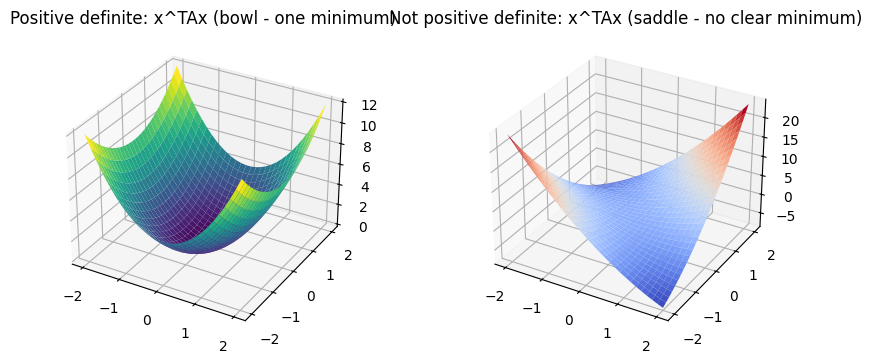

In [34]:
# Visual intuition: positive definite = bowl (single minimum). Not positive definite = saddle (no single minimum).
fig = plt.figure(figsize=(10, 4))
xx, yy = np.meshgrid(np.linspace(-2, 2, 30), np.linspace(-2, 2, 30))

A_pd = np.array([[2, 0], [0, 1]])
A_indef = np.array([[1, 2], [2, 1]])
zz_pd = A_pd[0,0]*xx**2 + 2*A_pd[0,1]*xx*yy + A_pd[1,1]*yy**2
zz_indef = A_indef[0,0]*xx**2 + 2*A_indef[0,1]*xx*yy + A_indef[1,1]*yy**2

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(xx, yy, zz_pd, cmap='viridis')
ax1.set_title('Positive definite: x^TAx (bowl - one minimum)')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(xx, yy, zz_indef, cmap='coolwarm')
ax2.set_title('Not positive definite: x^TAx (saddle - no clear minimum)')
plt.show()

## 21. Singular Value Decomposition (SVD) & PCA

SVD factors **any** matrix (square or not) into $X = U\Sigma V^T$: two rotations ($U$, $V$) and a scaling ($\Sigma$). PCA is what you get when you apply SVD to *standardized, mean-centered* data — the columns of $V$ become the principal components, ranked by how much variance they explain.

> 📺 **Suggested watch:** StatQuest — search `StatQuest Singular Value Decomposition PCA`

**Used in data science for:**
- **Dimensionality reduction** — compress 5 features (or 5,000) down to the 2-3 that capture most of the variance, for visualization, speed, or noise reduction.
- **Recommender systems** (matrix factorization of a user-item matrix), image compression, and topic modeling (LSA) are all SVD under the hood.
- This is the capstone of the notebook: it directly reuses eigenvectors (Sec 19), positive-definiteness (Sec 20, since covariance is always PSD), norms (Sec 16), and projections (Sec 15).

In [35]:
U, S, Vt = np.linalg.svd(Xstd, full_matrices=False)

print("Singular values:", S)
print("\nRelationship to eigenvalues of the covariance matrix (Section 19):")
print("  singular_values^2 / (n-1):", (S**2) / (n - 1))
print("  eigenvalues of cov, descending:", sorted(eigvals, reverse=True))
print("  -> they match! SVD of standardized data and eigendecomposition of its covariance are the same information.")

Singular values: [16.556 11.651 10.247  8.228  4.176]

Relationship to eigenvalues of the covariance matrix (Section 19):
  singular_values^2 / (n-1): [2.303 1.141 0.882 0.569 0.147]
  eigenvalues of cov, descending: [np.float64(2.3033333674515895), np.float64(1.1406971462728428), np.float64(0.8824393538844826), np.float64(0.5689744007396176), np.float64(0.14657253837415804)]
  -> they match! SVD of standardized data and eigendecomposition of its covariance are the same information.


Explained variance ratio per component: [0.457 0.226 0.175 0.113 0.029]
Top 2 components alone capture 68.3% of total variance.


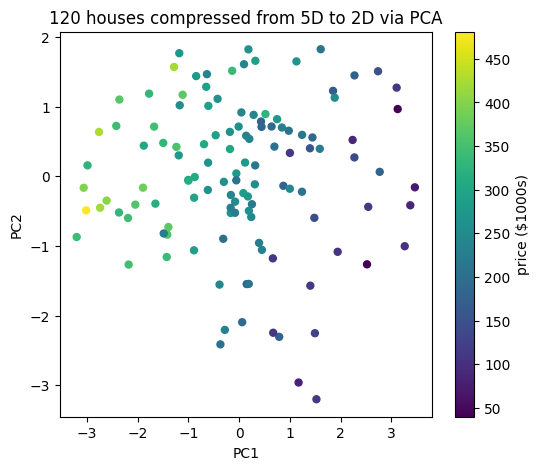


Notice PC1 alone roughly tracks price (color gradient runs left-to-right) -
that's expected, since size/bedrooms/garage (which drive price) are correlated and PC1 captures their shared direction.


In [36]:
# Project our 5D houses down to just the top 2 principal components
PC = Xstd @ Vt.T[:, :2]

explained = (S**2) / np.sum(S**2)
print("Explained variance ratio per component:", explained)
print(f"Top 2 components alone capture {explained[:2].sum()*100:.1f}% of total variance.")

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(PC[:, 0], PC[:, 1], c=df['price_1000s'], cmap='viridis', s=25)
plt.colorbar(sc, label='price ($1000s)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('120 houses compressed from 5D to 2D via PCA')
plt.show()

print("\nNotice PC1 alone roughly tracks price (color gradient runs left-to-right) -")
print("that's expected, since size/bedrooms/garage (which drive price) are correlated and PC1 captures their shared direction.")

In [37]:
# Cross-check our manual PCA against scikit-learn's implementation
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pc_sklearn = pca.fit_transform(Xstd)

print("sklearn explained variance ratio:", pca.explained_variance_ratio_)
print("Our manual explained variance ratio (top 2):", explained[:2])
print("\nComponents match (up to an arbitrary sign flip, which is mathematically inconsequential):",
      np.allclose(np.abs(PC), np.abs(pc_sklearn), atol=1e-6))

sklearn explained variance ratio: [0.457 0.226]
Our manual explained variance ratio (top 2): [0.457 0.226]

Components match (up to an arbitrary sign flip, which is mathematically inconsequential): True


## Wrap-up & Where This Connects

Every section used the **same 120-house dataset**, and the later sections leaned directly on the earlier ones:

- **Vectors → Dot product → Matrix multiplication** gave us `X @ weights` for instant predictions on all 120 houses.
- **Systems of equations → Gaussian elimination → Inverse** built up to the Normal Equation, `w = (X^TX)^{-1}X^Ty` — closed-form linear regression.
- **Determinants → Rank → Linear independence** were three increasingly robust ways of asking the same question: *"is any feature redundant?"*
- **Orthogonality → Projections** showed that regression residuals are always perpendicular to the features — not a coincidence, but the geometric definition of a "best fit."
- **Norms → Cosine similarity** powered Ridge regularization and a simple house-recommender.
- **Eigenvectors → Positive definiteness → SVD/PCA** closed the loop: PCA *is* eigendecomposition of a (guaranteed positive semi-definite) covariance matrix, and SVD is the numerically stable way to compute it.

### A couple of things worth double-checking with you
1. I used a **synthetic housing dataset** since you said "general dataset" without naming a domain — happy to regenerate everything against a different theme (e.g. customer churn, sensor readings, sports stats) if you'd prefer something closer to your actual use case.
2. Right now each section is fairly compact (explanation + 1-3 code cells). Let me know if you'd like any section expanded — e.g. **practice exercises with blank cells**, more advanced examples (regularization paths, gradient descent from scratch), or a section split into more granular sub-steps.